# ML & Forecasting voor Recommender Systems (MongoDB)

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pymongo import MongoClient

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

## 2. Connection to MongoDB

In [2]:
load_dotenv()

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB")

MONGODB_COLLECTION_RATINGS = os.getenv("MONGODB_COLLECTION_RATINGS", "reviews") # Of 'interactions'
MONGODB_COLLECTION_APPS = os.getenv("MONGODB_COLLECTION_APPS", "steam_apps")     # Voor game namen
MONGODB_COLLECTION_GAMES = os.getenv("MONGODB_COLLECTION_GAMES", "games")

if not MONGODB_URI or not MONGODB_DB:
    raise ValueError("Zet MONGODB_URI en MONGODB_DB in je .env bestand.")

client = MongoClient(MONGODB_URI)
db = client[MONGODB_DB]

## 3. Data ophalen uit MongoDB

In [3]:
print("Data ophalen uit MongoDB...")

# A. Ratings/Interactions ophalen
ratings_cursor = db[MONGODB_COLLECTION_RATINGS].find({})
ratings = pd.DataFrame(list(ratings_cursor))

# Kolomnamen standaardiseren
ratings = ratings.rename(columns={
    "SteamId": "user_id",
    "AppId": "app_id",
    "PlaytimeForever": "playtime_forever",
    "CreatedUtc": "review_date",
})

# B. Game metadata ophalen (voor leesbare aanbevelingen)
print("Game metadata ophalen...")
apps_cursor = db[MONGODB_COLLECTION_APPS].find({}, {"AppId": 1, "Name": 1, "_id": 0})
apps_df = pd.DataFrame(list(apps_cursor))
# Maak een lookup dictionary: ID -> Naam
id_to_name = {}
if not apps_df.empty:
    id_to_name = apps_df.set_index("AppId")["Name"].to_dict()

# C. Validatie van data
required_fields = {"user_id", "app_id"}
if not required_fields.issubset(set(ratings.columns)):
    raise ValueError(f"Verplichte velden ontbreken: {required_fields - set(ratings.columns)}")

# Impliciete feedback omzetten naar rating (Log transformatie voor playtime)
if "rating" not in ratings.columns:
    if "playtime_forever" in ratings.columns:
        # log1p zorgt dat 0 blijft 0, en vlakt extreme uitschieters af
        ratings["rating"] = np.log1p(ratings["playtime_forever"])
    else:
        raise ValueError("Geen 'rating' of 'playtime_forever' gevonden.")

print(f"Dataset ingeladen: {ratings.shape[0]} rijen.")
print(ratings.head())

Data ophalen uit MongoDB...
Game metadata ophalen...
Dataset ingeladen: 4066 rijen.
                        _id            user_id  app_id  playtime_forever  \
0  000000000000000000000000  76561198164987397     220             182.0   
1  69430a9999ef83246483b402  76561198080219056     220             793.0   
2  69430a9999ef83246483b403  76561198080219056     400             208.0   
3  69430a9999ef83246483b404  76561198080219056     550            1102.0   
4  69430a9999ef83246483b405  76561198080219056     620            1465.0   

   Playtime2Weeks             review_date              UpdatedUtc    rating  
0             0.0 2025-12-17 19:42:36.009 2026-01-02 16:51:39.402  5.209486  
1             0.0                     NaT 2025-12-17 19:55:04.152  6.677083  
2             0.0                     NaT 2025-12-17 19:55:04.152  5.342334  
3             0.0                     NaT 2025-12-17 19:55:04.152  7.005789  
4             0.0                     NaT 2025-12-17 19:55:04.152  7.

In [4]:
# ==========================================
# GAMES METADATA OPHALEN (SAFE VERSION)
# ==========================================

print("Games metadata ophalen...")

MONGODB_COLLECTION_GAMES = "games"  # Of "steam_apps" - je hebt 'games'

try:
    # 1. Controleer eerst hoeveel games er zijn
    total_games = db[MONGODB_COLLECTION_GAMES].count_documents({})
    print(f"Totaal games in database: {total_games}")
    
    # 2. Laad ALLEEN wat je nodig hebt (app_id + Name)
    # En gebruik een reasonable limit om niet overbelast te raken
    games_cursor = db[MONGODB_COLLECTION_GAMES].find(
        {},  # Geen filter - alles
        {
            "AppId": 1,      # Projectie: alleen deze velden
            "Name": 1,
            "_id": 0         # Exclude ObjectId
        }
    ).limit(50000)  # Veilige limit (aanpassen als nodig)
    
    # 3. Laad in chunks (niet alles in 1x)
    games_list = []
    for i, doc in enumerate(games_cursor):
        games_list.append(doc)
        if (i + 1) % 10000 == 0:
            print(f"  {i + 1} games geladen...")
    
    games = pd.DataFrame(games_list)
    print(f"✓ {len(games)} games ingeladen")
    
    # 4. Maak lookup dictionary
    if "AppId" in games.columns and "Name" in games.columns:
        id_to_name = dict(zip(games["AppId"], games["Name"]))
        print(f"✓ Lookup table gemaakt: {len(id_to_name)} games")
        
        # Laat een voorbeeld zien
        print("\nVoorbeelden:")
        for app_id, name in list(id_to_name.items())[:5]:
            print(f"  {app_id} → {name}")
    else:
        print(f"✗ Kolommen niet gevonden. Beschikbaar: {games.columns.tolist()}")
        id_to_name = {}
        
except Exception as e:
    print(f"✗ Fout bij ophalen games: {e}")
    print("  Dit kan gebeuren als de games-collectie erg groot is.")
    print("  Alternatie: zet LIMIT lager (bv. 10000 i.p.v. 50000)")
    id_to_name = {}

Games metadata ophalen...
Totaal games in database: 150405
  10000 games geladen...
  20000 games geladen...
  30000 games geladen...
  40000 games geladen...
  50000 games geladen...
✓ 50000 games ingeladen
✓ Lookup table gemaakt: 50000 games

Voorbeelden:
  10 → Counter-Strike
  20 → Team Fortress Classic
  30 → Day of Defeat
  40 → Deathmatch Classic
  50 → Half-Life: Opposing Force


## 4. Exploratory Data Analysis (EDA)


--- EDA ---
            rating  playtime_forever
count  4066.000000       4066.000000
mean      5.598679       2342.893999
std       2.030284      12671.006343
min       0.693147          1.000000
25%       4.317488         74.000000
50%       5.650732        283.500000
75%       6.883206        974.750000
max      12.984808     435742.000000


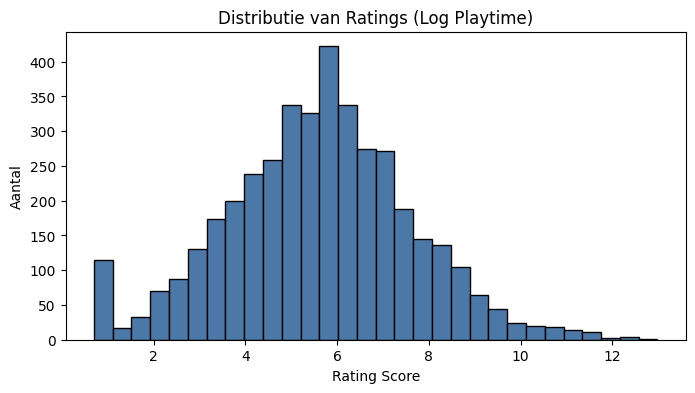

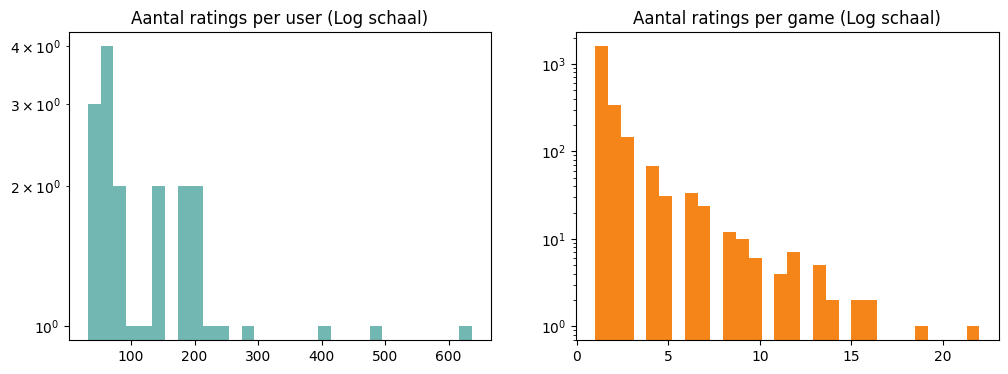

In [5]:
print("\n--- EDA ---")
print(ratings[["rating", "playtime_forever"]].describe())

# Visualisatie 1: Rating distributie
plt.figure(figsize=(8, 4))
plt.hist(ratings["rating"], bins=30, color="#4C78A8", edgecolor='black')
plt.title("Distributie van Ratings (Log Playtime)")
plt.xlabel("Rating Score")
plt.ylabel("Aantal")
plt.show()

# Visualisatie 2: Long-tail check
user_counts = ratings["user_id"].value_counts()
item_counts = ratings["app_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_counts, bins=30, log=True, color="#72B7B2")
axes[0].set_title("Aantal ratings per user (Log schaal)")
axes[1].hist(item_counts, bins=30, log=True, color="#F58518")
axes[1].set_title("Aantal ratings per game (Log schaal)")
plt.show()

## 5. Preprocessing & filtering

In [6]:
MIN_USER_RATINGS = 5
MIN_ITEM_RATINGS = 5

print(f"Filtering: Minimaal {MIN_USER_RATINGS} ratings per user, {MIN_ITEM_RATINGS} per item.")
filtered = ratings.copy()
filtered = filtered[filtered["user_id"].map(user_counts) >= MIN_USER_RATINGS]
filtered = filtered[filtered["app_id"].map(item_counts) >= MIN_ITEM_RATINGS]

print(f"Shape na filtering: {filtered.shape}")

Filtering: Minimaal 5 ratings per user, 5 per item.
Shape na filtering: (1091, 8)


## 6. Train/test split (user-level)

In [7]:
def user_train_test_split(df, test_size=0.2, random_state=42, time_col="review_date"):
    """
    Splitst data per user. Als er tijdsdata is, gebruiken we de laatste X% interacties
    als testdata (realistisch scenario). Anders random split.
    """
    train_rows = []
    test_rows = []
    has_time = time_col in df.columns

    for user_id, group in df.groupby("user_id"):
        # Te weinig data om te splitsen? Alles naar train.
        if len(group) < 2:
            train_rows.append(group)
            continue

        if has_time:
            g = group.copy()
            g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
            g = g.sort_values(time_col)
            
            valid_dates = g[time_col].notna().sum()
            if valid_dates >= 2:
                split_idx = max(1, int(len(g) * (1 - test_size)))
                train_rows.append(g.iloc[:split_idx])
                test_rows.append(g.iloc[split_idx:])
                continue

        # Fallback: Random split
        train, test = train_test_split(group, test_size=test_size, random_state=random_state)
        train_rows.append(train)
        test_rows.append(test)

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True) if test_rows else df.iloc[0:0]
    return train_df, test_df

train_df, test_df = user_train_test_split(filtered, test_size=0.2)
print(f"Train set: {train_df.shape}, Test set: {test_df.shape}")

Train set: (864, 8), Test set: (227, 8)


In [8]:
# Pivot table: Rijen=Items, Kolommen=Users
# Let op: Bij miljoenen rijen is scipy.sparse.csr_matrix beter, maar voor deze schaal is pivot prima.
item_user_matrix = train_df.pivot_table(
    index="app_id", columns="user_id", values="rating", fill_value=0
)

print("KNN Model fitten...")
model_knn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
model_knn.fit(item_user_matrix)

KNN Model fitten...


NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1)

## 7. Recommender: Item-based Collaborative Filtering (cosine)

In [9]:
def recommend_items(user_id, knn_model, matrix, train_data, top_k=5, seed_k=3, neighbor_k=20, seasonal_index=None, seasonal_weight=0.0):
    if user_id not in matrix.columns:
        return [] # Cold start user

    # 1. Haal items op die de user al heeft (Seed items)
    user_history = train_data[train_data["user_id"] == user_id]
    
    # Sorteer op rating (hoogste eerst) en pak de top seed_k
    seeds = user_history.sort_values("rating", ascending=False).head(seed_k)["app_id"].tolist()
    owned_items = set(user_history["app_id"].tolist())

    scores = {}

    # 2. Zoek buren voor elk seed item
    for item_id in seeds:
        if item_id not in matrix.index:
            continue
        
        # Zoek nearest neighbors van dit item
        item_vec = matrix.loc[[item_id]]
        distances, indices = knn_model.kneighbors(item_vec, n_neighbors=neighbor_k)
        
        # 3. Score aggregatie
        for dist, idx in zip(distances.flatten(), indices.flatten()):
            neighbor_id = matrix.index[idx]
            
            # Sla over als user het al heeft of als het het item zelf is
            if neighbor_id in owned_items or neighbor_id == item_id:
                continue
            
            # Similarity score (1 - cosine distance)
            similarity = 1.0 - dist
            scores[neighbor_id] = scores.get(neighbor_id, 0) + similarity

    # 4. (Optioneel) seizoensboost toepassen
    if seasonal_index:
        for item_id in list(scores.keys()):
            season_factor = seasonal_index.get(item_id, 1.0)
            scores[item_id] = scores[item_id] * (1 + seasonal_weight * (season_factor - 1))

    # 5. Sorteren en top-k teruggeven
    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in ranked_items[:top_k]]

# Helper voor pretty printen
def _pretty(item_ids):
    return [f"{i}: {id_to_name.get(i, 'Unknown')}" for i in item_ids]

# Testje met een user
sample_user = train_df["user_id"].iloc[0]
recs = recommend_items(sample_user, model_knn, item_user_matrix, train_df, top_k=5)
print(f"Voorbeeld aanbevelingen voor user {sample_user}:")
print(_pretty(recs))

Voorbeeld aanbevelingen voor user 76561197987819677:
["4000: Garry's Mod", '304930: Unturned', '367520: Hollow Knight', '105600: Terraria', '2567870: Unknown']


In [10]:
debug_users = train_df['user_id'].drop_duplicates().head(3).tolist()
neighbor_grid = [5, 10, 20, 40]

def _pretty(items):
    # show both id and title if available
    out = []
    for a in items:
        title = id_to_name.get(a) if 'id_to_name' in globals() else None
        out.append(f"{a} ({title})" if title else str(a))
    return out

for u in debug_users:
    print(f"\nUser {u}")
    recs_by_n = {}
    for n in neighbor_grid:
        tmp = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=n)
        tmp.fit(item_user_matrix)
        recs = recommend_items(u, tmp, item_user_matrix, train_df, top_k=5, seed_k=3, neighbor_k=n)
        recs_by_n[n] = recs
        print(f"  n={n}: {_pretty(recs)}")

    # show overlap between smallest and largest
    a, b = set(recs_by_n[neighbor_grid[0]]), set(recs_by_n[neighbor_grid[-1]])
    jacc = len(a & b) / len(a | b) if (a | b) else 0
    print(f"  Jaccard(top-5 {neighbor_grid[0]} vs {neighbor_grid[-1]}) = {jacc:.2f}")


User 76561197987819677
  n=5: ['212910', '1977530', '239140 (Dying Light)', '739630 (Phasmophobia)', "4000 (Garry's Mod)"]
  n=10: ['212910', '1977530', '239140 (Dying Light)', '739630 (Phasmophobia)', "4000 (Garry's Mod)"]
  n=20: ["4000 (Garry's Mod)", '304930 (Unturned)', '367520 (Hollow Knight)', '105600 (Terraria)', '2567870']
  n=40: ['346110 (ARK: Survival Evolved)', '700330 (SCP: Secret Laboratory)', '304930 (Unturned)', '550 (Left 4 Dead 2)', '578080 (PUBG: BATTLEGROUNDS)']
  Jaccard(top-5 5 vs 40) = 0.00

User 76561198021592344
  n=5: ['578080 (PUBG: BATTLEGROUNDS)']
  n=10: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)']
  n=20: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)', '212910', '346110 (ARK: Survival Evolved)', '200210 (Realm of the Mad God Exalt)']
  n=40: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)', '570 (Dota 2)', '346110 (ARK: Survival Evolved)', '431960']
  Jaccard(top-5 5 vs 40) = 0.20

User 76561198031182634
  n=5: ['1966720', '3

## 8. Evaluatie: Precision/Recall + MAE/RMSE

In [11]:
def evaluate_model(knn_model, matrix, train_data, test_data, k=5, seed_k=3, neighbor_k=20):
    hits = 0
    total_relevant = 0
    total_recommended = 0
    
    # Evalueer alleen users die in de test set zitten
    test_users = test_data["user_id"].unique()
    
    for u in test_users:
        # Ground truth: wat heeft de user in de test set gedaan?
        true_items = set(test_data[test_data["user_id"] == u]["app_id"])
        if not true_items:
            continue
            
        # Voorspelling
        recs = recommend_items(u, knn_model, matrix, train_data, top_k=k, seed_k=seed_k, neighbor_k=neighbor_k)
        
        # Berekening
        intersection = len(true_items & set(recs))
        hits += intersection
        total_relevant += len(true_items)
        total_recommended += len(recs)
        
    precision = hits / total_recommended if total_recommended > 0 else 0
    recall = hits / total_relevant if total_relevant > 0 else 0
    return precision, recall

print("--- Evaluatie Start ---")
prec, rec = evaluate_model(model_knn, item_user_matrix, train_df, test_df)
print(f"Model Performance (k=5): Precision={prec:.4f}, Recall={rec:.4f}")

# MAE/RMSE evaluatie op rating-schatting (baseline)
def baseline_rating_metrics(train_data, test_data):
    if train_data.empty or test_data.empty:
        return None, None
    global_mean = train_data["rating"].mean()
    item_means = train_data.groupby("app_id")["rating"].mean()
    preds = test_data["app_id"].map(item_means).fillna(global_mean)
    mae = mean_absolute_error(test_data["rating"], preds)
    rmse = root_mean_squared_error(test_data["rating"], preds)
    return mae, rmse

mae, rmse = baseline_rating_metrics(train_df, test_df)
if mae is not None:
    print(f"Baseline Rating Metrics: MAE={mae:.4f}, RMSE={rmse:.4f}")

--- Evaluatie Start ---
Model Performance (k=5): Precision=0.1565, Recall=0.0793
Baseline Rating Metrics: MAE=1.3419, RMSE=1.7732


## 9. Cross-validation (user-level)

In [26]:
def cross_validate_knn(df, n_splits=3, k=5, neighbor_k=20, seed_k=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df), 1):
        train_fold = df.iloc[train_idx]
        test_fold = df.iloc[test_idx]

        fold_matrix = train_fold.pivot_table(index="app_id", columns="user_id", values="rating", fill_value=0)
        
        # FIX: Controleer hoeveel games (samples) er in de matrix zitten
        n_samples_in_fold = fold_matrix.shape[0]
        # Gebruik de kleinste waarde: de gewenste neighbor_k of het aantal beschikbare games
        actual_neighbors = min(neighbor_k, n_samples_in_fold)
        
        if actual_neighbors < 1:
            continue

        # Gebruik actual_neighbors voor de initialisatie
        fold_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=actual_neighbors, n_jobs=-1)
        fold_model.fit(fold_matrix)

        # Geef ook actual_neighbors door aan de evaluatie
        p, r = evaluate_model(fold_model, fold_matrix, train_fold, test_fold, k=k, seed_k=seed_k, neighbor_k=actual_neighbors)
        rows.append({"fold": fold, "precision": p, "recall": r})

    return pd.DataFrame(rows)

# De aanroep werkt nu omdat neighbor_k in de definitie staat
print("\n--- Cross-validation ---")
cv_results = cross_validate_knn(filtered, n_splits=3, k=20, neighbor_k=125)
if not cv_results.empty:
    print(cv_results)
    print("\nGemiddelde resultaten:")
    print(cv_results.mean(numeric_only=True))


--- Cross-validation ---
   fold  precision    recall
0     1   0.213043  0.269231
1     2   0.228261  0.288462
2     3   0.230435  0.292011

Gemiddelde resultaten:
fold         2.000000
precision    0.223913
recall       0.283234
dtype: float64


## 10. Hyperparameter optimalisatie


--- Hyperparameter Tuning ---
   n_neighbors  precision    recall
2           50   0.226087  0.114537
1           20   0.156522  0.079295
0           10   0.149533  0.070485


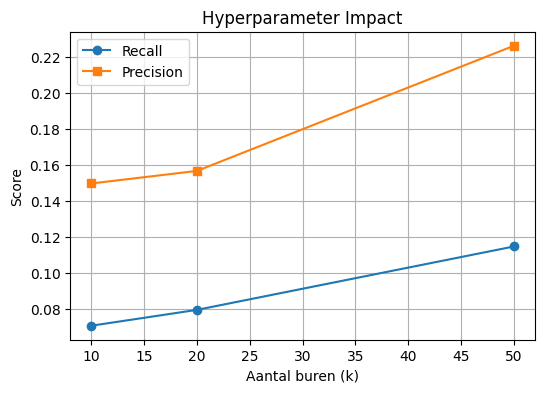

In [ ]:
print("\n--- Hyperparameter Tuning ---")
neighbor_grid = [10, 20, 50]
results = []

for n in neighbor_grid:
    # Train nieuw model met n neighbors
    tmp_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=n, n_jobs=-1)
    tmp_model.fit(item_user_matrix)
    
    p, r = evaluate_model(tmp_model, item_user_matrix, train_df, test_df, neighbor_k=n)
    results.append({"n_neighbors": n, "precision": p, "recall": r})

results_df = pd.DataFrame(results)
print(results_df.sort_values("recall", ascending=False))

# Plot resultaten
plt.figure(figsize=(6, 4))
plt.plot(results_df["n_neighbors"], results_df["recall"], marker='o', label="Recall")
plt.plot(results_df["n_neighbors"], results_df["precision"], marker='s', label="Precision")
plt.xlabel("Aantal buren (k)")
plt.ylabel("Score")
plt.title("Hyperparameter Impact")
plt.legend()
plt.grid(True)
plt.show()

## 11. Forecasting: seizoensgebonden trends


--- Forecasting Analysis ---
Dagen met activiteit: 6 (lege dagen verwijderd)
Opstartfase gefilterd: eerste 1 actieve dagen genegeerd.
Aantal bruikbare datapunten (na filtering): 5
Forecast MAE: 1715.25
Trend: GROEIEND (Hellingshoek: 635.50 interacties/dag)


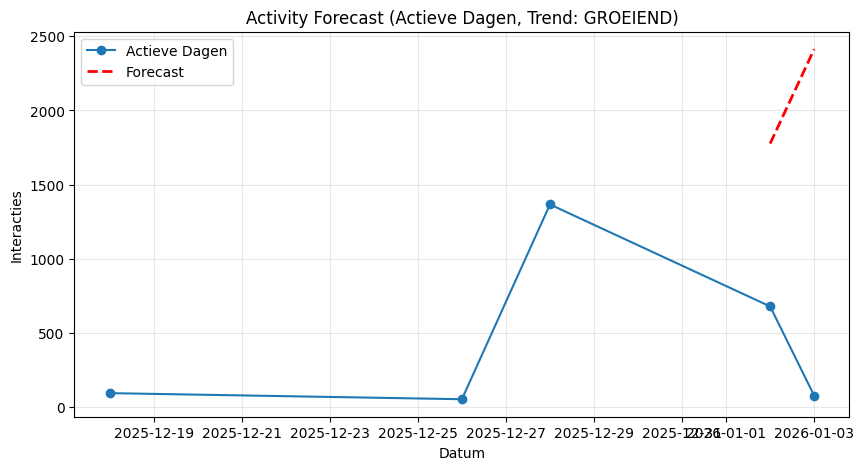

In [ ]:
print("\n--- Forecasting Analysis ---")

if "review_date" in ratings.columns:
    ratings["review_date"] = pd.to_datetime(ratings["review_date"], errors="coerce")
    
    if "UpdatedUtc" in ratings.columns:
        ratings["UpdatedUtc"] = pd.to_datetime(ratings["UpdatedUtc"], errors="coerce")
        ratings["review_date"] = ratings["review_date"].combine_first(ratings["UpdatedUtc"])

    valid_dates = ratings.dropna(subset=["review_date"]).copy()
    
    # Aggregeren per DAG
    ts_data = valid_dates.set_index("review_date").resample("D").size().reset_index(name="count")
    
    ts_data = ts_data[ts_data["count"] > 0].copy().reset_index(drop=True)
    
    print(f"Dagen met activiteit: {len(ts_data)} (lege dagen verwijderd)")

    # Outlier filtering (eerste 20%)
    if len(ts_data) > 5:
        cutoff_index = int(len(ts_data) * 0.2)
        ts_clean = ts_data.iloc[cutoff_index:].copy().reset_index(drop=True)
        print(f"Opstartfase gefilterd: eerste {cutoff_index} actieve dagen genegeerd.")
    else:
        ts_clean = ts_data.copy()

    print(f"Aantal bruikbare datapunten (na filtering): {len(ts_clean)}")

    # 3. Minimaal 3 punten nodig
    if len(ts_clean) >= 3:
        ts_clean["time_idx"] = np.arange(len(ts_clean))
        
        split_idx = len(ts_clean) - 2
        if split_idx < 2: split_idx = len(ts_clean) - 1
        
        train_ts = ts_clean.iloc[:split_idx]
        test_ts = ts_clean.iloc[split_idx:]

        # Model
        X_train, y_train = train_ts[["time_idx"]], train_ts["count"]
        X_test, y_test = test_ts[["time_idx"]], test_ts["count"]

        reg = LinearRegression()
        reg.fit(X_train, y_train)
        
        preds = np.maximum(reg.predict(X_test), 0)
        
        mae = mean_absolute_error(y_test, preds)
        trend_coef = reg.coef_[0]
        trend_status = "GROEIEND" if trend_coef > 0 else "DALEND"

        print(f"Forecast MAE: {mae:.2f}")
        print(f"Trend: {trend_status} (Hellingshoek: {trend_coef:.2f} interacties/dag)")

        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(ts_clean["review_date"], ts_clean["count"], label="Actieve Dagen", marker='o', color='tab:blue')
        plt.plot(test_ts["review_date"], preds, label="Forecast", linestyle="--", color='red', linewidth=2)
        
        plt.title(f"Activity Forecast (Actieve Dagen, Trend: {trend_status})")
        plt.xlabel("Datum")
        plt.ylabel("Interacties")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"Te weinig data ({len(ts_clean)} dagen).")
else:
    print("Geen datum kolom beschikbaar.")